# Estimator MSE

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from joblib import Parallel, delayed
from pthin import pthin, pcarve_estimate, truncgauss_estimate

rng = np.random.default_rng(0)

## File drawer problem

Each "study" draws a single test statistic $X \sim N(\mu, 1)$ and is only
estimated if it clears a one-sided significance threshold at level $\alpha$
against the null $\mu = 0$ -- the classic file-drawer problem: only
"significant" studies get published/analyzed, and naively estimating $\mu$
from the published subset overstates it (winner's curse).

We compare five ways of estimating $\mu$ conditional on selection, mirroring
`hypothesis_testing.ipynb`'s methods:

- **Naive** (`scheme1`-style raw statistic, grey): select and estimate using
  the same $X$ -- double dipping, no correction.
- **Data thinning** (independence): split $X$ into independent
  $X_1, X_2 \sim N(\mu/\sqrt2, 1)$ via added Gaussian noise; select on $X_1$,
  estimate $\sqrt2\, X_2$. Unbiased because $X_2 \perp X_1$, so conditioning
  on the selection event (a function of $X_1$ alone) does not bias $X_2$.
- **Truncated Gaussian (csi)**: select on $X$ directly, correct via the
  exact conditional-selective-inference likelihood (`truncgauss_estimate`).
- **p-thinning**: select on a thinned p-value $p_1$ derived from $X$'s
  p-value (`pthin`), correct via the p-value-masking conditional likelihood
  (`pcarve_estimate`).

For csi and p-thinning we compare their `"mle"`, `"mean"`, and `"combined"`
estimators. All four selection rules are calibrated to the same nominal
level $\alpha$ (each is exactly or approximately $\mathrm{Unif}(0,1)$-valued
under the null, so `Pr(selected | mu=0) = alpha` for all of them).

`pcarve_estimate`'s `"mean"` is the expensive step (a numerical-integration
grid per call); we use loosened quadrature tolerance and a coarser grid
(`epsabs=epsrel=1e-4`, `n_points=41`) as in `normal_ci.ipynb`, and
parallelize the per-replicate point estimates with `joblib`. Expect this
notebook to take on the order of several minutes to run in full.

In [42]:
def draw_selected_batch(mu, alpha, n_target, rng, batch_size=200_000, max_total=5_000_000):
    """Draw batches of studies until >= n_target selected instances are found
    for each of the four selection rules (naive and csi share one; thinning
    and p-thinning have their own), returning the *pre-selection* statistic
    each method would go on to estimate from.
    """
    c_alpha = norm.isf(alpha)
    collected = {"naive": [], "thinning": [], "csi": [], "pthin": []}
    n_drawn = 0
    while n_drawn < max_total:
        have_enough = all(
            sum(len(chunk) for chunk in v) >= n_target for v in collected.values()
        )
        if have_enough:
            break

        X = rng.normal(mu, 1, size=batch_size)
        p = norm.sf(X)  # one-sided p-value against theta0=0
        p1, _ = pthin(p, epsilon=0.5, rng=rng)
        W = rng.normal(0, 1, size=batch_size)
        X1 = (X + W) / np.sqrt(2)
        X2 = (X - W) / np.sqrt(2)

        def take(key, mask, values):
            have = sum(len(chunk) for chunk in collected[key])
            if have >= n_target:
                return
            idx = np.flatnonzero(mask)[: n_target - have]
            collected[key].append(values[idx])

        take("naive", X >= c_alpha, X)
        take("csi", X >= c_alpha, X)
        take("thinning", X1 >= c_alpha, X2)
        take("pthin", p1 <= alpha, X)

        n_drawn += batch_size

    selected = {k: (np.concatenate(v) if v else np.array([])) for k, v in collected.items()}
    return selected, c_alpha


def csi_point_estimates(x, c_alpha):
    mle = truncgauss_estimate(x, c=c_alpha, estimator="mle")
    mean = truncgauss_estimate(x, c=c_alpha, estimator="mean")
    return mle, mean, (mle + mean) / 2


def pcarve_point_estimates(x, alpha):
    mle = pcarve_estimate(
        x, 0.0, a=0.0, b=alpha, epsilon=0.5, estimator="mle", input_type="statistic",
        epsabs=1e-4, epsrel=1e-4, limit=50,
    )
    mean = pcarve_estimate(
        x, 0.0, a=0.0, b=alpha, epsilon=0.5, estimator="mean", input_type="statistic",
        epsabs=1e-4, epsrel=1e-4, limit=50, n_points=41,
    )
    return mle, mean, (mle + mean) / 2

In [65]:
mus = [1, 2, 4, 8]
alphas = [0.001, 0.01, 0.1]
N_TARGET = 500  # selected reps per (mu, alpha) cell; raise for smoother curves, at the cost of runtime

batches = {}  # (alpha, mu) -> (selected dict, c_alpha)
mse = {alpha: {"naive": {}, "thinning": {}} for alpha in alphas}
jobs = []  # (alpha, mu, method, x) for the csi/p-thinning point estimators

for alpha in alphas:
    for mu in mus:
        selected, c_alpha = draw_selected_batch(mu, alpha, N_TARGET, rng)
        batches[(alpha, mu)] = (selected, c_alpha)

        mse[alpha]["naive"][mu] = np.median(np.abs(selected["naive"] - mu))
        mse[alpha]["thinning"][mu] = np.median(np.abs(np.sqrt(2) * selected["thinning"] - mu))

        jobs.extend((alpha, mu, "csi", x) for x in selected["csi"])
        jobs.extend((alpha, mu, "pthin", x) for x in selected["pthin"])

print(f"{len(jobs)} point-estimate jobs queued")

12000 point-estimate jobs queued


In [ ]:
def compute_job(job):
    alpha, mu, method, x = job
    if method == "csi":
        c_alpha = batches[(alpha, mu)][1]
        mle, mean, combined = csi_point_estimates(x, c_alpha)
    else:
        mle, mean, combined = pcarve_point_estimates(x, alpha)
    return alpha, mu, method, mle, mean, combined


job_results = Parallel(n_jobs=-1)(delayed(compute_job)(job) for job in jobs)

sq_errors = {
    alpha: {
        mu: {
            "csi": {"mle": [], "mean": [], "combined": []},
            "pthin": {"mle": [], "mean": [], "combined": []},
        }
        for mu in mus
    }
    for alpha in alphas
}

for alpha, mu, method, mle, mean, combined in job_results:
    sq_errors[alpha][mu][method]["mle"].append((mle - mu) ** 2)
    sq_errors[alpha][mu][method]["mean"].append((mean - mu) ** 2)
    sq_errors[alpha][mu][method]["combined"].append((combined - mu) ** 2)

/Users/rflperry/Documents/UW/daniela_ra/pval_thinning/pthin/estimate.py:235: IntegrationWarning: The algorithm does not converge.  Roundoff error is detected
  in the extrapolation table.  It is assumed that the requested tolerance
  cannot be achieved, and that the returned result (if full_output = 1) is 
  the best which can be obtained.
  numerator, _ = quad(lambda theta: theta * likelihood(theta), -np.inf, np.inf, limit=200)
/Users/rflperry/Documents/UW/daniela_ra/pval_thinning/pthin/estimate.py:234: IntegrationWarning: The algorithm does not converge.  Roundoff error is detected
  in the extrapolation table.  It is assumed that the requested tolerance
  cannot be achieved, and that the returned result (if full_output = 1) is 
  the best which can be obtained.
  total, _ = quad(likelihood, -np.inf, np.inf, limit=200)
/Users/rflperry/Documents/UW/daniela_ra/pval_thinning/pthin/estimate.py:235: IntegrationWarning: The algorithm does not converge.  Roundoff error is detected
  in the 

In [60]:
import pickle
filename = "../results/filedrawer_errors.pkl"
with open(filename, "wb") as f:
    pickle.dump(sq_errors, f)

In [ ]:
with open("../results/filedrawer_errors.pkl", 'rb') as f:
    sq_errors = pickle.load(f)

In [66]:
for alpha in alphas:
    for prefix, agg in zip(["csi", "pthin"], [np.median, np.median]):
        for variant in ["mle", "mean", "combined"]:
            mse[alpha].setdefault(f"{prefix}_{variant}", {})
            for mu in mus:
                mse[alpha][f"{prefix}_{variant}"][mu] = agg(
                    np.sqrt(sq_errors[alpha][mu][prefix][variant])
                )

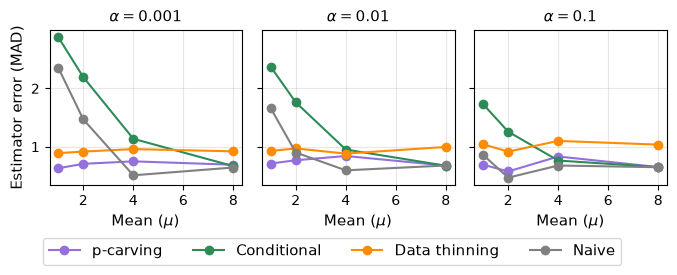

In [80]:
# Colors matching hypothesis_testing.ipynb; grey for naive. Purple for pthin, which is actually pcarve
colors = {
    "pthin": 'mediumpurple',# "steelblue",  
    "csi": "seagreen",
    "thinning": "darkorange",
    "naive": "grey",
}
# Distinct line + marker style per estimator variant.
variant_style = {
    "mle": dict(linestyle="-", marker="o"),
    "mean": dict(linestyle="--", marker="s"),
    "combined": dict(linestyle="-", marker="o"),
}
single_style = dict(linestyle="-", marker="o")

labels = {
    "naive": "Naive",
    "thinning": "Data thinning",
    "csi_mle": "Conditional (MLE)",
    "csi_mean": "Conditional (mean)",
    "csi_combined": "Conditional", # (combined)
    "pthin_mle": "p-carving (MLE)",
    "pthin_mean": "p-carving (mean)",
    "pthin_combined": "p-carving", # (combined)
}

fig, axes = plt.subplots(1, 3, figsize=(7, 2.5), sharey=True)

for ax, alpha in zip(axes, alphas):
    for method in ["pthin_combined"]: # "pthin_mle", "pthin_mean", 
        variant = method.split("_", 1)[1]
        ax.plot(
            mus, [mse[alpha][method][mu] for mu in mus],
            color=colors["pthin"], label=labels[method], **variant_style[variant],
        )
    for method in ["csi_combined"]: # "csi_mle", "csi_mean", 
        variant = method.split("_", 1)[1]
        ax.plot(
            mus, [mse[alpha][method][mu] for mu in mus],
            color=colors["csi"], label=labels[method], **variant_style[variant],
        )
    ax.plot(
        mus, [mse[alpha]["thinning"][mu] for mu in mus],
        color=colors["thinning"], label=labels["thinning"], **single_style,
    )
    ax.plot(
        mus, [mse[alpha]["naive"][mu] for mu in mus],
        color=colors["naive"], label=labels["naive"], **single_style,
    )

    # ax.set_yscale("log")
    # ax.set_ylim([0, 3])
    ax.set_xlabel(r"Mean ($\mu$)", fontsize=11)
    ax.set_title(rf"$\alpha = {alpha}$", fontsize=11)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Estimator error (MAD)", fontsize=11)
handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, legend_labels, loc="upper center", bbox_to_anchor=(0.5, 0.06),
    ncol=4, frameon=True, fontsize=11,
)
plt.tight_layout()
plt.savefig("../figures/file_drawer_estimator_mad.png", dpi=300, bbox_inches='tight')
plt.show()

## Winner's curse

Mirrors `hypothesis_testing.ipynb`'s "Winner's curse" section, but for point
estimation rather than testing/CIs. Each replicate draws `N_TOTAL_WC`
competing studies; the first has true mean $\mu$ (the "winner"), the second
has true mean $\mu \times$ `gap_ratio` (the "near winner"), and the rest are
null. Only the apparent winner (by whichever selection rule) is analyzed, and
its point estimate is compared to *its own* true mean -- which is $\mu$ if
the real winner was selected, $\mu \times$ `gap_ratio` if the near winner was
mistakenly selected instead, or $0$ if a null study won. Panels vary the
"near winner gap" $= 1 -$ `gap_ratio` over $[1, 0.5, 0]$ (`gap_ratio` over
$[0, 0.5, 1]$): gap $0$ is the hardest case, a true tie between the winner
and the near winner. As with the file-drawer comparison, only the combined
estimator is shown for csi/p-carving.

In [72]:
def draw_winners_curse_reps(mu, gap_ratio, N_total, n_reps, rng):
    """Draw n_reps winner's-curse replicates of N_total competing studies
    (only the apparent winner from each selection rule is analyzed),
    returning per-method inputs to the point estimators.
    """
    naive_sq_err = []
    thin_sq_err = []
    csi_jobs = []    # (x_obs, c_cond, true_mu)
    pthin_jobs = []  # (x_obs, b, true_mu)

    for _ in range(n_reps):
        X = rng.normal(0, 1, size=N_total)
        X[0] += mu
        X[1] += mu * gap_ratio
        p = norm.sf(X)

        # --- naive & csi share the argmax(X) selection event ---
        sel = np.argmax(X)
        true_mu = mu if sel == 0 else (mu * gap_ratio if sel == 1 else 0.0)
        naive_sq_err.append(np.abs(X[sel] - true_mu))
        c_cond = np.sort(X)[-2]
        csi_jobs.append((X[sel], c_cond, true_mu))

        # --- data thinning ---
        W = rng.normal(0, 1, size=N_total)
        X1 = (X + W) / np.sqrt(2)
        X2 = (X - W) / np.sqrt(2)
        sel_dt = np.argmax(X1)
        true_mu_dt = mu if sel_dt == 0 else (mu * gap_ratio if sel_dt == 1 else 0.0)
        thin_sq_err.append(np.abs(np.sqrt(2) * X2[sel_dt] - true_mu_dt))

        # --- p-thinning ---
        p1, _ = pthin(p, epsilon=0.5, rng=rng)
        sel_p = np.argmin(p1)
        true_mu_p = mu if sel_p == 0 else (mu * gap_ratio if sel_p == 1 else 0.0)
        b = np.sort(p1)[1]
        pthin_jobs.append((X[sel_p], b, true_mu_p))

    return naive_sq_err, thin_sq_err, csi_jobs, pthin_jobs

In [73]:
mus_wc = [1, 2, 4, 8]
gap_ratios = [0, 0.5, 1]  # panel title shows gap = 1 - gap_ratio -> [1, 0.5, 0]
N_TOTAL_WC = 10
N_REPS_WC = 500

mse_wc = {g: {"naive": {}, "thinning": {}, "csi_combined": {}, "pthin_combined": {}} for g in gap_ratios}
wc_jobs = []  # (gap_ratio, mu, method, x, param, true_mu)

for gap_ratio in gap_ratios:
    for mu in mus_wc:
        naive_sq, thin_sq, csi_jobs, pthin_jobs = draw_winners_curse_reps(
            mu, gap_ratio, N_TOTAL_WC, N_REPS_WC, rng
        )
        mse_wc[gap_ratio]["naive"][mu] = np.median(naive_sq)
        mse_wc[gap_ratio]["thinning"][mu] = np.median(thin_sq)
        wc_jobs.extend((gap_ratio, mu, "csi", x, c, t) for x, c, t in csi_jobs)
        wc_jobs.extend((gap_ratio, mu, "pthin", x, b, t) for x, b, t in pthin_jobs)

print(f"{len(wc_jobs)} winner's-curse point-estimate jobs queued")

12000 winner's-curse point-estimate jobs queued


In [49]:
def compute_wc_job(job):
    gap_ratio, mu, method, x, param, true_mu = job
    if method == "csi":
        mle = truncgauss_estimate(x, c=param, estimator="mle")
        mean = truncgauss_estimate(x, c=param, estimator="mean")
    else:
        mle = pcarve_estimate(
            x, 0.0, a=0.0, b=param, epsilon=0.5, estimator="mle", input_type="statistic",
            epsabs=1e-4, epsrel=1e-4, limit=50,
        )
        mean = pcarve_estimate(
            x, 0.0, a=0.0, b=param, epsilon=0.5, estimator="mean", input_type="statistic",
            epsabs=1e-4, epsrel=1e-4, limit=50, n_points=41,
        )
    combined = (mle + mean) / 2
    return gap_ratio, mu, method, (combined - true_mu) ** 2


wc_job_results = Parallel(n_jobs=-1)(delayed(compute_wc_job)(job) for job in wc_jobs)

wc_sq_errors = {g: {mu: {"csi": [], "pthin": []} for mu in mus_wc} for g in gap_ratios}
for gap_ratio, mu, method, sq_err in wc_job_results:
    wc_sq_errors[gap_ratio][mu][method].append(sq_err)

In [74]:
for gap_ratio in gap_ratios:
    for mu in mus_wc:
        mse_wc[gap_ratio]["csi_combined"][mu] = np.median(np.sqrt(wc_sq_errors[gap_ratio][mu]["csi"]))
        mse_wc[gap_ratio]["pthin_combined"][mu] = np.median(np.sqrt(wc_sq_errors[gap_ratio][mu]["pthin"]))

In [53]:
import pickle
with open("../results/winners_curse_errors.pkl", "wb") as f:
    pickle.dump(wc_sq_errors, f)

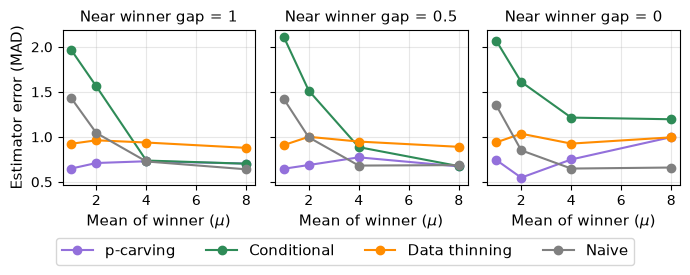

In [78]:
# Reuses colors/single_style/labels defined in the file-drawer plotting cell above.
fig, axes = plt.subplots(1, 3, figsize=(7, 2.5), sharey=True)

for ax, gap_ratio in zip(axes, gap_ratios):
    ax.plot(
        mus_wc, [mse_wc[gap_ratio]["pthin_combined"][mu] for mu in mus_wc],
        color=colors["pthin"], label=labels["pthin_combined"], **single_style,
    )
    ax.plot(
        mus_wc, [mse_wc[gap_ratio]["csi_combined"][mu] for mu in mus_wc],
        color=colors["csi"], label=labels["csi_combined"], **single_style,
    )
    ax.plot(
        mus_wc, [mse_wc[gap_ratio]["thinning"][mu] for mu in mus_wc],
        color=colors["thinning"], label=labels["thinning"], **single_style,
    )
    ax.plot(
        mus_wc, [mse_wc[gap_ratio]["naive"][mu] for mu in mus_wc],
        color=colors["naive"], label=labels["naive"], **single_style,
    )

    # ax.set_ylim([0, 10])
    ax.set_xlabel(r"Mean of winner ($\mu$)", fontsize=11)
    ax.set_title(f"Near winner gap = {1 - gap_ratio}", fontsize=11)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Estimator error (MAD)", fontsize=11)
handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, legend_labels, loc="upper center", bbox_to_anchor=(0.5, 0.06),
    ncol=4, frameon=True, fontsize=11,
)
plt.tight_layout()
plt.savefig("../figures/winners_curse_estimator_mad.png", dpi=300, bbox_inches="tight")
plt.show()